In [52]:
!pip install -q tensorflow tensorflow-datasets keras-tuner

# Importing libraries

In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds
import keras_tuner as kt
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow:", tf.__version__)
#print("TFDS:", tfds.__version__)

TensorFlow: 2.20.0


In [ ]:
import tensorflow_datasets as tfds

print(tfds)
print(dir(tfds)[:20])
print(getattr(tfds, "__file__", "No file"))

<module 'tensorflow_datasets' from '/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py'>
['GenerateMode', 'ImageFolder', 'ReadConfig', 'Split', 'TranslateFolder', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'annotations', 'as_dataframe', 'as_numpy', 'audio']
/usr/local/lib/python3.12/dist-packages/tensorflow_datasets/__init__.py


# Load Malaria Dataset

In [ ]:
builder = tfds.builder("malaria")

builder.download_and_prepare()

dataset = builder.as_dataset(as_supervised=True)

full_dataset = dataset["train"]

print(full_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>


# Split Dataset into Train and Test

In [ ]:
dataset_size = 27558

train_size = int(0.8 * dataset_size)

train_ds = full_dataset.take(train_size)
test_ds = full_dataset.skip(train_size)

print("Training Samples:", train_size)
print("Testing Samples:", dataset_size - train_size)

Training Samples: 22046
Testing Samples: 5512


# Visualize Images

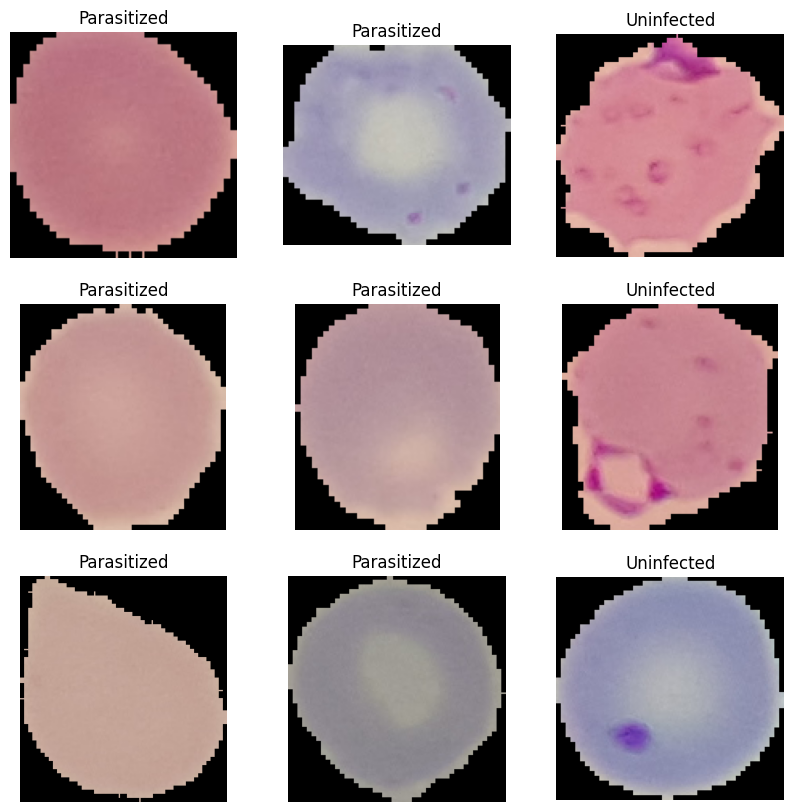

In [ ]:
plt.figure(figsize=(10,10))

for i, (image, label) in enumerate(train_ds.take(9)):
    plt.subplot(3,3,i+1)

    plt.imshow(image.numpy())

    if label.numpy() == 1:
        plt.title("Parasitized")
    else:
        plt.title("Uninfected")

    plt.axis("off")

plt.show()

# Preprocessing

In [ ]:

IMG_SIZE = 128
BATCH_SIZE = 32

def preprocess(image, label):

    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
    image = image / 255.0

    return image, label

train_ds = train_ds.map(preprocess)
test_ds = test_ds.map(preprocess)

train_ds = train_ds.shuffle(1000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

# Build CNN Model

In [ ]:
model = tf.keras.Sequential([

    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(128,128,3)
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

# Compiling the model

In [ ]:

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Training the model

In [ ]:

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 47ms/step - accuracy: 0.8516 - loss: 0.3401 - val_accuracy: 0.9398 - val_loss: 0.1796
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 45ms/step - accuracy: 0.9490 - loss: 0.1608 - val_accuracy: 0.9526 - val_loss: 0.1621
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 40s 43ms/step - accuracy: 0.9567 - loss: 0.1357 - val_accuracy: 0.9559 - val_loss: 0.1437
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 38s 54ms/step - accuracy: 0.9599 - loss: 0.1217 - val_accuracy: 0.9550 - val_loss: 0.1427
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 45ms/step - accuracy: 0.9621 - loss: 0.1109 - val_accuracy: 0.9552 - val_loss: 0.1484
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 41s 45ms/step - accuracy: 0.9663 - loss: 0.0980 - val_accuracy: 0.9532 - val_loss: 0.1480
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 31s 44ms/step - accuracy: 0.9691 - loss: 0.0905 - val_accuracy: 0.9546 - val_loss: 0.1527
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 32s 46ms/step - accuracy: 0.9728 - loss: 0.0763 - 

# Evaluating the model

In [ ]:
loss, accuracy = model.evaluate(test_ds)

print("Test Accuracy:", accuracy)

173/173 ━━━━━━━━━━━━━━━━━━━━ 14s 22ms/step - accuracy: 0.9521 - loss: 0.2116
Test Accuracy: 0.9521045088768005


# Plot the accuracy

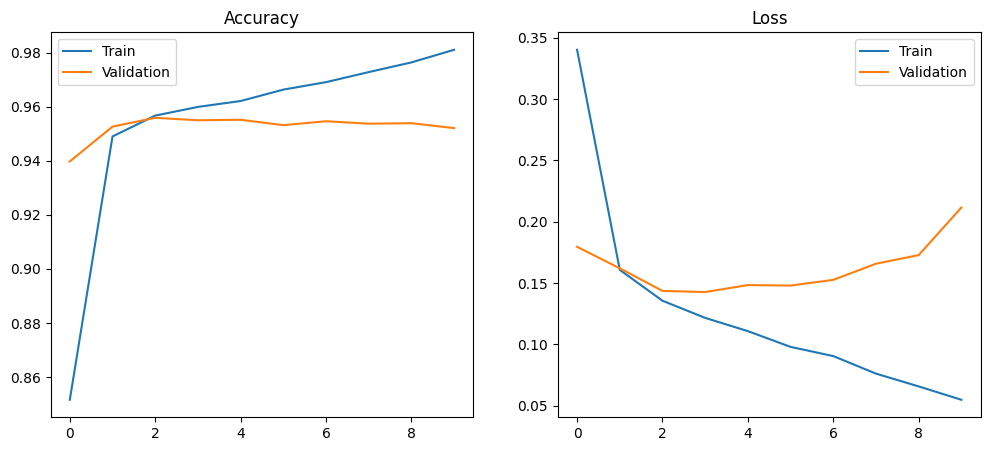

In [ ]:

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Accuracy")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.show()

# Save the model

In [ ]:
model.save("malaria_classifier.h5")